In [1]:
%pip install --quiet --upgrade \
    google-ml-edu==0.1.3 \
    keras~=3.8.0 \
    matplotlib~=3.10.0 \
    numpy~=2.0.0 \
    pandas~=2.2.0 \
    tensorflow~=2.18.0

print("\n\nAll requirements successfully installed (hopefully)!")
print("Now try: import tensorflow as tf; print(tf.__version__)")

Note: you may need to restart the kernel to use updated packages.


All requirements successfully installed (hopefully)!
Now try: import tensorflow as tf; print(tf.__version__)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:

print("\n\nAll requirements successfully installed (hopefully)!")



All requirements successfully installed (hopefully)!


In [1]:
%pip install --quiet plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#@title Code - Load dependencies

# data
import numpy as np
import pandas as pd

# machine learning
import keras
import ml_edu.experiment
import ml_edu.results

# data visualization
import plotly.express as px

In [6]:

chicago_taxi_dataset = pd.read_csv("C:/Users/priya/Desktop/folders/project_/chicago_taxi_train.csv")

In [7]:
chicago_taxi_dataset

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.00,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.00,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.00,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.00,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.00,0.0,0.0,0.0,10.00,Cash,Flash Cab
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31689,05/17/2022 1:15:00 PM,05/17/2022 1:30:00 PM,13.25,739,13.06,63.6,NaN,NaN,75.0,28.0,32.50,0.00,0.0,0.0,0.0,32.50,Prcard,Blue Ribbon Taxi Association
31690,05/17/2022 9:45:00 PM,05/17/2022 10:15:00 PM,21.75,1740,30.90,63.9,NaN,NaN,76.0,NaN,44.50,10.00,13.9,0.0,27.5,82.00,Credit Card,Choice Taxi Association
31691,05/18/2022 3:45:00 AM,05/18/2022 4:00:00 AM,3.75,687,12.21,64.0,NaN,NaN,22.0,NaN,30.75,0.00,0.0,0.0,0.0,30.75,Prcard,Sun Taxi
31692,05/16/2022 2:45:00 PM,05/16/2022 3:30:00 PM,14.75,2040,36.60,64.6,NaN,NaN,76.0,7.0,41.75,11.55,25.2,0.0,4.0,57.30,Credit Card,"Taxicab Insurance Agency, LLC"


In [10]:
training_df = chicago_taxi_dataset.loc[:,('TRIP_MILES','TRIP_SECONDS','FARE','COMPANY','PAYMENT_TYPE','TIP_RATE')]
training_df.head(200)

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


In [12]:
#title Code - View dataset statistics

training_df.describe(include='all')

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,8.289463,1319.796397,23.905210,NaN,NaN,12.965785
std,7.265672,928.932873,16.970022,NaN,NaN,15.517765
min,0.500000,60.000000,3.250000,NaN,NaN,0.000000
25%,1.720000,548.000000,9.000000,NaN,NaN,0.000000
50%,5.920000,1081.000000,18.750000,NaN,NaN,12.200000
75%,14.500000,1888.000000,38.750000,NaN,NaN,20.800000


In [15]:
# What is the maximum fare?
max_fare = training_df['FARE'].max()
print("What is the maximum fare Answer: ",max_fare)

What is the maximum fare Answer:  159.25


In [17]:

# What is the mean distance across all trips?
mean_distance = training_df['TRIP_MILES'].mean()
print("What is the mean distance across all trips? " ,mean_distance)


What is the mean distance across all trips?  8.289462674323214


In [18]:
# Are any features missing data?
missing_values = training_df.isnull().sum().sum()
print("Are any features missing data? 			Answer:", "No" if missing_values == 0 else "Yes")

Are any features missing data? 			Answer: No


In [19]:
#@title Code - View correlation matrix
training_df.corr(numeric_only = True)

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [20]:
#@title Double-click to view answers about the correlation matrix

# Which feature correlates most strongly to the label FARE?
answer = '''
The feature with the strongest correlation to the FARE is TRIP_MILES.
As you might expect, TRIP_MILES looks like a good feature to start with to train
the model. Also, notice that the feature TRIP_SECONDS has a strong correlation
with fare too.
'''
print(answer)


# Which feature correlates least strongly to the label FARE?
answer = '''The feature with the weakest correlation to the FARE is TIP_RATE.'''
print(answer)


The feature with the strongest correlation to the FARE is TRIP_MILES.
As you might expect, TRIP_MILES looks like a good feature to start with to train
the model. Also, notice that the feature TRIP_SECONDS has a strong correlation
with fare too.

The feature with the weakest correlation to the FARE is TIP_RATE.


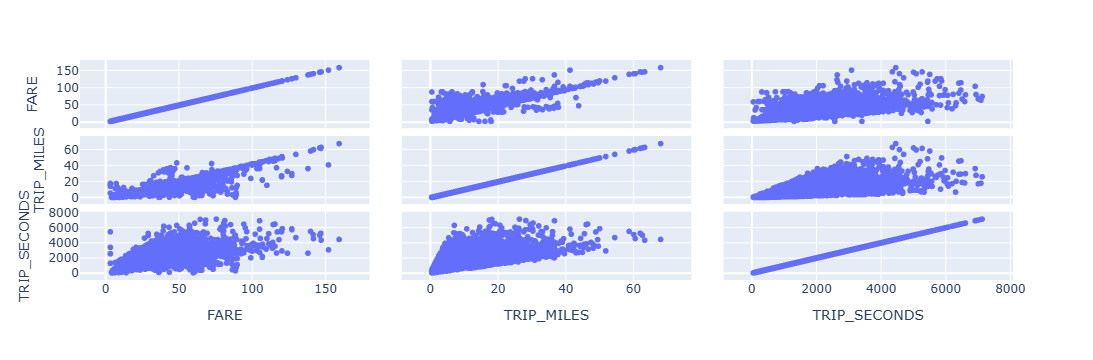

In [21]:
#@title Code - View pairplot
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])

In [22]:
#@title Code - Define ML functions

def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
  """Create and compile a simple linear regression model."""
  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  outputs = keras.layers.Dense(units=1)(concatenated_inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # Compile the model topography into code that Keras can efficiently
  # execute. Configure training to minimize the model's mean squared error.
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs.
  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.


In [8]:
# 1. Import the important things
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 2. Our fake (but realistic) data
# House sizes in square feet (X = feature)
sizes = np.array([ 800, 950, 1000, 1200, 1250, 1400, 1600, 1800, 2000, 2400 ])

# House prices in lakh rupees (y = target)
prices = np.array([ 32, 38,  41,  48,  50,  56,  64,  72,  80,  96 ])

# Important: sklearn wants 2D array for X → we reshape
X = sizes.reshape(-1, 1)      # now shape is (10,1)
y = prices

# 3. Create and train the model (literally 2 lines!)
model = LinearRegression()
model.fit(X, y)


# 5. Predict some new houses
new_sizes = np.array([1100, 1500, 2100]).reshape(-1,1)
predictions = model.predict(new_sizes)

print("Predictions:",predictions)

Predictions: [44.16423358 60.08866466 83.97531129]


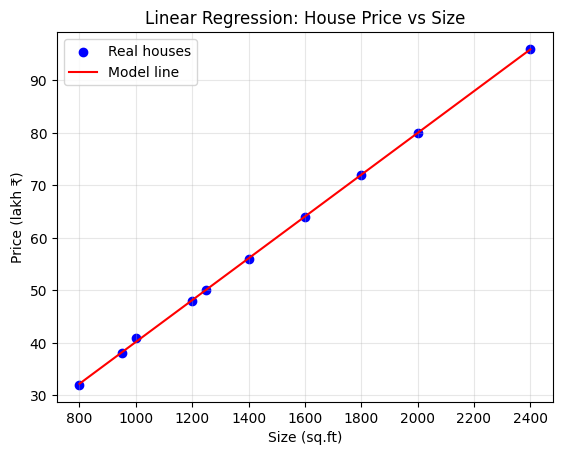

In [7]:
# Optional: plot what we learned
plt.scatter(sizes, prices, color='blue', label='Real houses')
plt.plot(sizes, model.predict(X), color='red', label='Model line')
plt.xlabel("Size (sq.ft)")
plt.ylabel("Price (lakh ₹)")
plt.title("Linear Regression: House Price vs Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
hours = np.array([2.5,5.0,1.0,4.5,3.2,6.8,7.5,8.0,2.8,9.0,1.5,3.8,5.5,6.2,4.0]).reshape(-1,1)
scores = np.array([45,68,32,62,55,78,85,88,48,92,38,58,72,75,60])

model=LinearRegression()
model.fit(hours,scores)
new_=np.array([[3],[2.6]])
prediction_=model.predict(new_);
print(prediction_)

[50.49661441 47.47683062]
